In [1]:
import sys, os
repo_root = os.path.abspath(os.path.join(os.getcwd()))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import importlib
from functools import partial

import matplotlib.pyplot as plt
import numpy as np  
from IPython.display import display
import pandas as pd 

import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_networkx

In [2]:
# Reproducibility
SEED = 123123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True 
np.random.seed(SEED)

In [3]:
DATASET_NAME = "MUTAG"

In [4]:
config = {
    "DATASET_NAME": DATASET_NAME, 
    "device": "cuda",
    "explainee": {
        "epochs": 200, 
        "batch_size": 64, 
        "lr": 1e-2
    }, 
    "ged_model": {
        "n_perds": 4, 
        "epochs": 100, 
        "batch_size": 64, 
    }, 
    "tune": {
        "n_trials": 8, 
        "max_nodes": 24, 
        "iters_per_sample": 16, 
        "samples_per_trial": 8, # Note: per class. 
    },
    "train": {
        "iters_per_sample": 200, 
        "samples_per_trial": 50, # Note: per class. 
    }
}

# Data

In [5]:
import new_src.dataAdapter
from new_src.dataAdapter import load_dataset
importlib.reload(new_src.dataAdapter)

data = load_dataset(config.get("DATASET_NAME"))
cls_split = data.split_by_class()

# Explainee

In [6]:
import new_src.explainee
from new_src.explainee import fit_explainee
importlib.reload(new_src.explainee)

explainee, _ = fit_explainee(
    dataset_name = config.get("DATASET_NAME"),
    root="data",
    hidden=64,
    layers=3,
    dropout=0.2,
    epochs=config["explainee"]["epochs"],
    batch_size=config["explainee"]["batch_size"],
    lr=config["explainee"]["lr"],
    device=config.get("device")
)


# Extract embeddings. 
mean_embeds = [
    torch.cat([explainee(batch.to(config.get("device")))["embeds"]
               for batch in DataLoader(subset, batch_size=64)])
         .mean(dim=0)
    for subset in cls_split
]
mean_embeds = [m.detach() for m in mean_embeds]

[001/200] train_loss=0.7601  val_acc=0.684
[002/200] train_loss=0.6034  val_acc=0.684
[003/200] train_loss=0.5898  val_acc=0.684
[004/200] train_loss=0.5747  val_acc=0.684
[005/200] train_loss=0.5488  val_acc=0.842
[006/200] train_loss=0.5255  val_acc=0.684
[007/200] train_loss=0.5427  val_acc=0.842
[008/200] train_loss=0.5008  val_acc=0.842
[009/200] train_loss=0.5138  val_acc=0.842
[010/200] train_loss=0.5245  val_acc=0.842
[011/200] train_loss=0.4930  val_acc=0.789
[012/200] train_loss=0.4910  val_acc=0.842
[013/200] train_loss=0.4713  val_acc=0.842
[014/200] train_loss=0.4677  val_acc=0.842
[015/200] train_loss=0.4680  val_acc=0.842
[016/200] train_loss=0.4662  val_acc=0.789
[017/200] train_loss=0.4781  val_acc=0.789
[018/200] train_loss=0.4736  val_acc=0.842
[019/200] train_loss=0.4470  val_acc=0.737
[020/200] train_loss=0.4400  val_acc=0.789
[021/200] train_loss=0.4399  val_acc=0.789
[022/200] train_loss=0.4278  val_acc=0.789
[023/200] train_loss=0.4650  val_acc=0.842
[024/200] t

# GED Approximator

Generating synthetic GED dataset with 4 perturbations per graph...
Created GED dataset with 752 pairs.


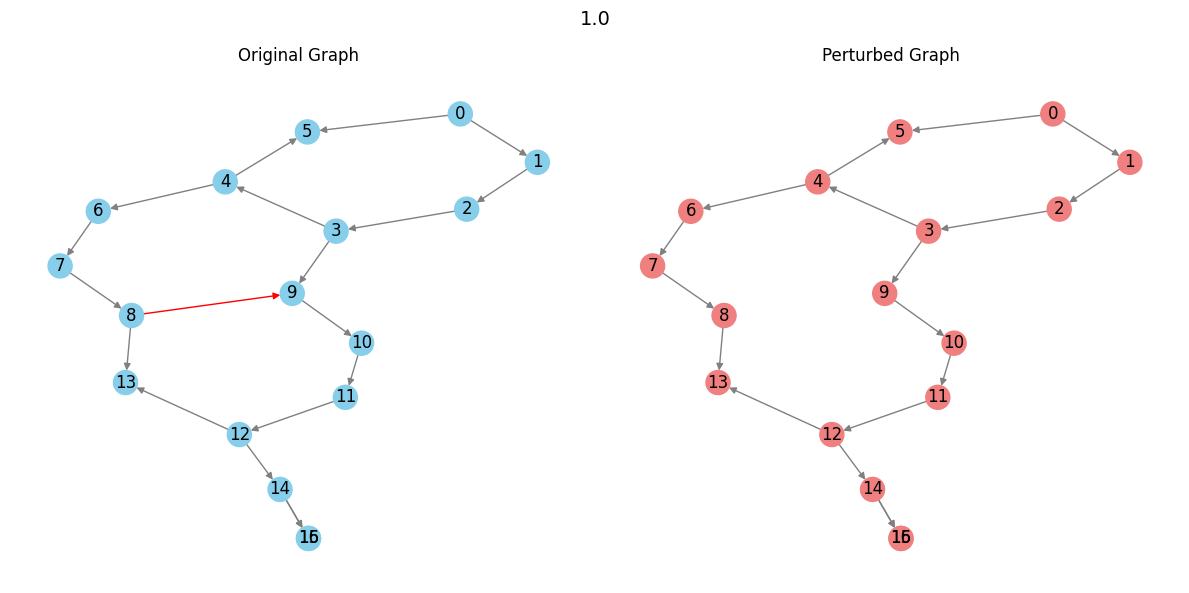

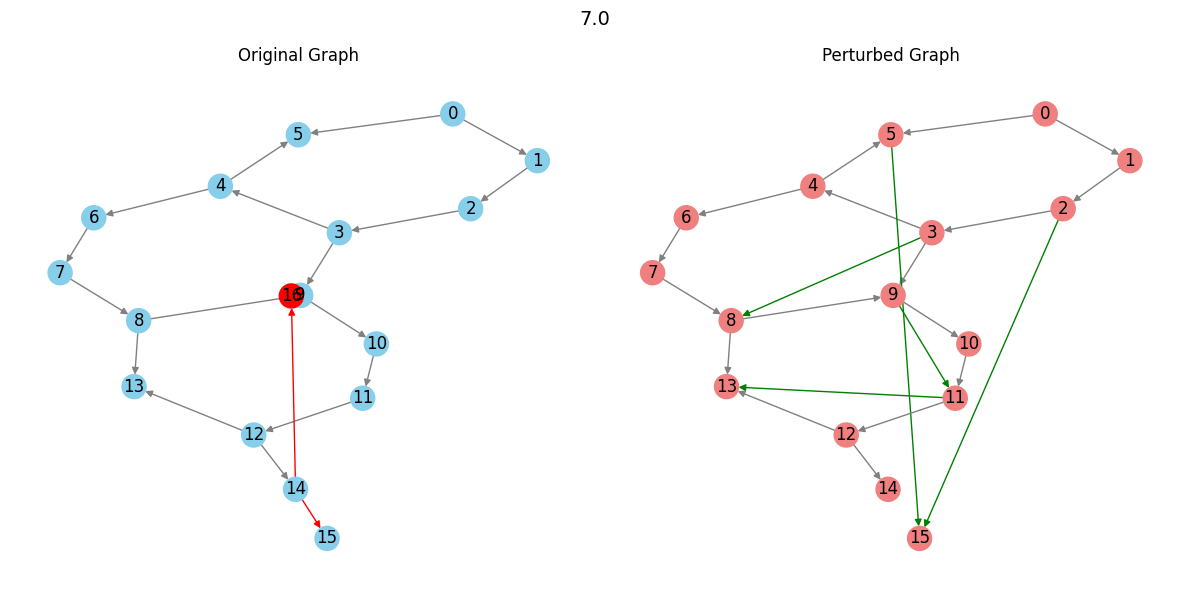

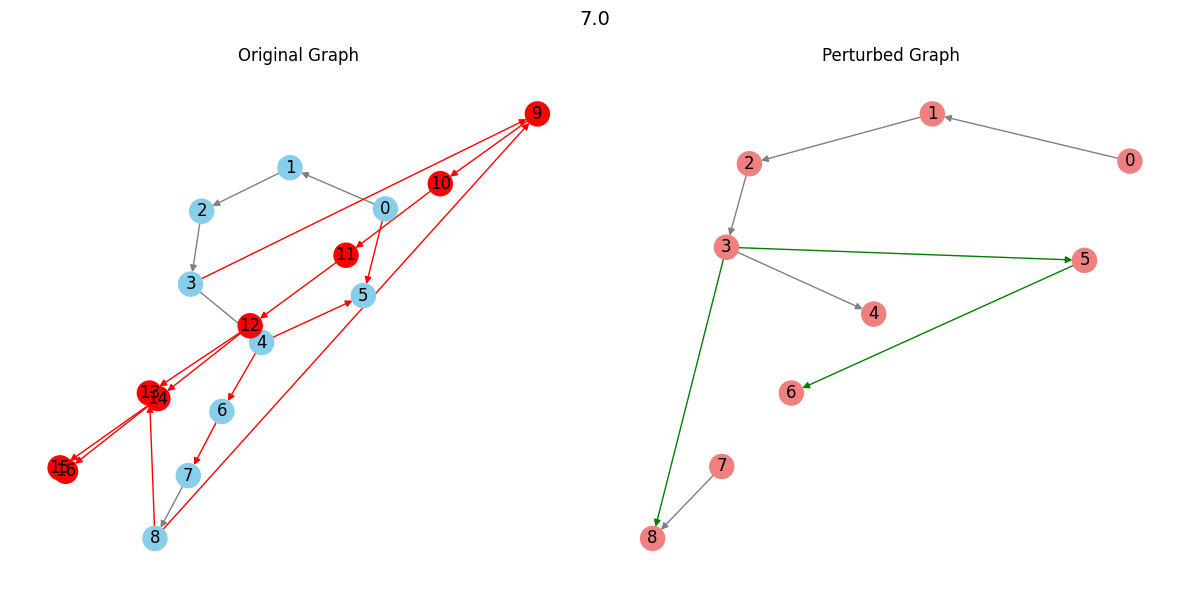

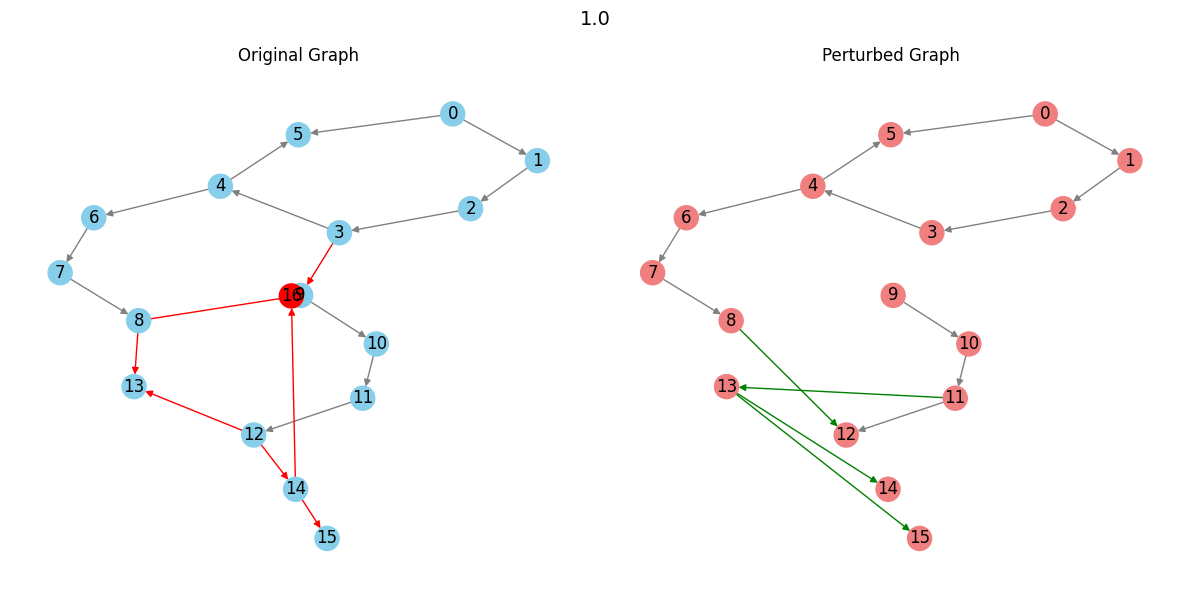

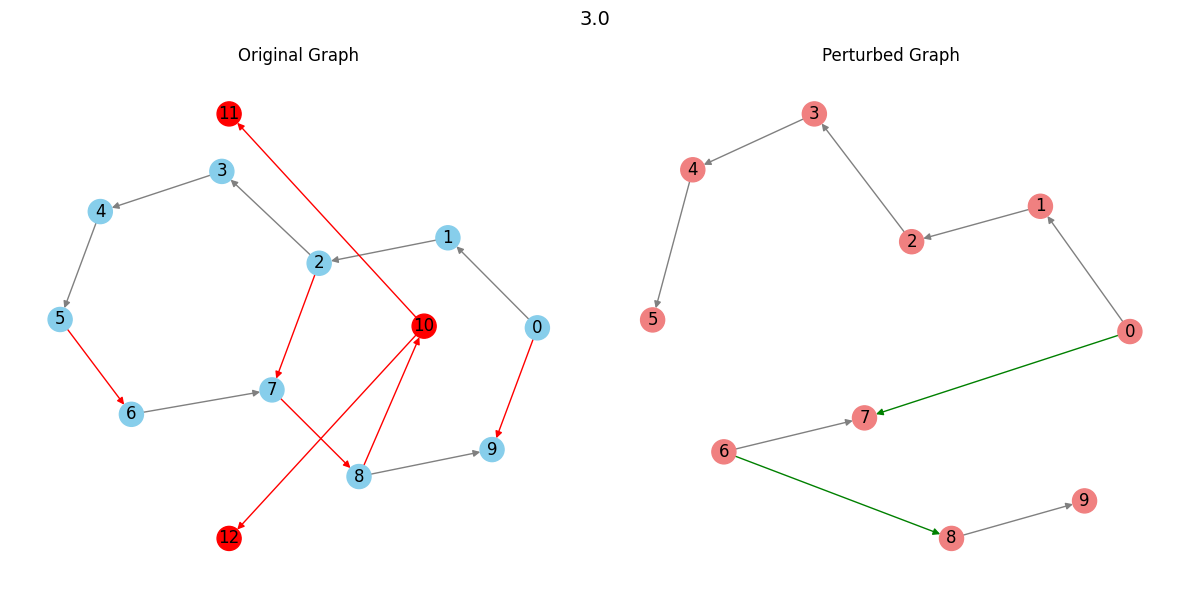

In [7]:
import new_src.ged_dataset
importlib.reload(new_src.ged_dataset)

from new_src.ged_dataset import create_and_save_ged_dataset, plot_graph_pair

ged_dataset = create_and_save_ged_dataset(
    data, 
    out_path=None, 
    n_perturbations=config["ged_model"]["n_perds"],
    node_add_prob=0.5,
    node_remove_prob=0.5,
    edge_add_prob=0.1, 
    edge_remove_prob=0.1
)

print(f"Created GED dataset with {len(ged_dataset)} pairs.")

for i in range(5):
    g1, g2, ged_norm, _, _ = ged_dataset[i]
    raw_ged = getattr(g1, "raw_ged", ged_norm)
    plot_graph_pair(g1, g2, label=raw_ged)

In [8]:
import new_src.simgnn
importlib.reload(new_src.simgnn)

from new_src.simgnn import SimGNN, train_simgnn

model = SimGNN(in_dim=len(data.NODE_CLS))

train_simgnn(
    model=(m := model), 
    data=ged_dataset, 
    batch_size=config["ged_model"]["batch_size"], 
    optimizer=(o := torch.optim.Adam(m.parameters(), lr=1e-2)),
    scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
    epochs=config["ged_model"]["epochs"], 
    device=config.get("device")
)

Training SimGNN:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 001 | Loss: 3.0100 | MSE(norm): 3.0100 | MSE(raw): 1719.6581 | Corr(norm): -0.0089 | Corr(raw): 0.0751
Epoch 002 | Loss: 0.1647 | MSE(norm): 0.1647 | MSE(raw): 78.9294 | Corr(norm): 0.0949 | Corr(raw): 0.4401
Epoch 003 | Loss: 0.1452 | MSE(norm): 0.1452 | MSE(raw): 65.1086 | Corr(norm): 0.1717 | Corr(raw): 0.5440
Epoch 004 | Loss: 0.1514 | MSE(norm): 0.1514 | MSE(raw): 74.0453 | Corr(norm): 0.1216 | Corr(raw): 0.4757
Epoch 005 | Loss: 0.1531 | MSE(norm): 0.1531 | MSE(raw): 71.7545 | Corr(norm): 0.1139 | Corr(raw): 0.4946
Epoch 006 | Loss: 0.1415 | MSE(norm): 0.1415 | MSE(raw): 65.9565 | Corr(norm): 0.1055 | Corr(raw): 0.5078
Epoch 007 | Loss: 0.1427 | MSE(norm): 0.1427 | MSE(raw): 66.9529 | Corr(norm): 0.1281 | Corr(raw): 0.5016
Epoch 008 | Loss: 0.1345 | MSE(norm): 0.1345 | MSE(raw): 61.8664 | Corr(norm): 0.1487 | Corr(raw): 0.5392
Epoch 009 | Loss: 0.1392 | MSE(norm): 0.1392 | MSE(raw): 64.2676 | Corr(norm): 0.1363 | Corr(raw): 0.5322
Epoch 010 | Loss: 0.1325 | MSE(norm): 0.132

# Generator

In [9]:
# All passes should be explicit. 
def train_generator(
    cls_idx, 
    max_nodes, 
    iters_per_sample, 
    data, 
    mean_embeds, 
    explainee, 
    ged_model, 
    w_pred=1,
    w_embed=1,
    w_ged=1,
    w_mcs=1,
    w_spec=1,
    w_wl=1,
    use_omega=False,  
):

    from new_src.graph_sampler import GraphSampler
    from new_src.trainer import Trainer
    from new_src.criteria import (
        WeightedCriterion, 
        ClassScoreCriterion, 
        EmbeddingCriterion, 
        BudgetPenalty
    )
    
    from new_src.graph_level_dist import (
        neural_approx_ged_dist, 
        mcs_soft_graph_dist, 
        spectral_dist, 
        wl_graph_kernel_dist
    )
    
    trainer = Trainer(
        sampler=(
            s := GraphSampler(
                    max_nodes=max_nodes,
                    num_node_cls=len(data.NODE_CLS),
                    num_edge_cls=len(data.EDGE_CLS), 
                    temperature=0.15,
                    learn_node_feat=len(data.NODE_CLS) > 0, 
                    learn_edge_feat=len(data.EDGE_CLS) > 0, 
            )
        ),
        discriminator=explainee,
        criterion=WeightedCriterion([
            dict(key="logits", 
                criterion=ClassScoreCriterion(
                    class_idx=cls_idx, mode='maximize'
                ), 
                weight=w_pred
            ),
            dict(key="embeds", 
                criterion=EmbeddingCriterion(
                    target_embedding=mean_embeds[cls_idx]
                ), 
                weight=w_embed
            ),
            dict(key="cont_data", 
                criterion=neural_approx_ged_dist(
                    data = data, model = ged_model, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_ged
            ), 
            dict(key="cont_data", 
                criterion=mcs_soft_graph_dist(
                    data = data, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_mcs
            ), 
            dict(key="cont_data", 
                criterion=spectral_dist(
                    data = data, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_spec
            ), 
            dict(key="cont_data", 
                criterion=wl_graph_kernel_dist(
                    data = data, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_wl
            ), 
        ]),
        optimizer=(o := torch.optim.SGD(s.parameters(), lr=1)),
        scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
        dataset=data,
        budget_penalty=BudgetPenalty(budget=20, order=2, beta=1),
        device=config.get("device")
    )

    trainer.train(
        iterations=iters_per_sample,
        target_probs={cls_idx: (0.9, 1.0)},
        target_size=30,
        w_budget_init=0.5,
        w_budget_inc=1.1,
        w_budget_dec=0.95,
        k_samples=32
    )

    example = trainer.evaluate(threshold=0.5)

    example = from_networkx(example)

    if "label" in example: 
        example.x = F.one_hot(
            example.label, num_classes=len(data.NODE_CLS)
        ).float()

    if "edge_label" in example: 
        example.edge_attr = F.one_hot(
            example.edge_label, num_classes=len(data.EDGE_CLS)
        ).float()

    example.y = torch.tensor(cls_idx).float()
    
    return example

## Tuning

In [10]:
import ray
from ray import tune
from ray import air
from ray.tune import ExperimentAnalysis
ray.shutdown()
ray.init(
    runtime_env={
        "py_modules": ["/repo/revisions/new_src"]
    },
    num_gpus=1
)

data_ref = ray.put(data)
mean_embeds_ref = ray.put(mean_embeds)
cls_split_ref = ray.put(data.split_by_class())

2025-11-12 04:20:49,985	WARNING services.py:2155 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 67104768 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=10.24gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2025-11-12 04:20:50,221	INFO worker.py:2012 -- Started a local Ray instance.
2025-11-12 04:20:50,577	INFO packaging.py:588 -- Creating a file package for local module '/repo/revisions/new_src'.
2025-11-12 04:20:51,137	INFO packaging.py:380 -- Pushing file package 'gcs://_ray_pkg_0763045b3f3ad372.zip' (0.39MiB) to Ray cluster...
2025-11-12 04:20:51,141	INFO packaging.py:393 -- Successfully pushed file package 'gcs://_ray_pkg_0763045b3f3ad372.zip'.
/opt/venv/lib/python3.12/site-packages/ray/_private/worker

In [11]:
def tune_generator(
    config, *,
    explainee, 
    model, 
    max_nodes, 
    gen_samples, 
    iters_per_sample, 
):
    from new_src.eval import eval_summary
    from new_src.graph_level_dist import neural_approx_ged_dist

    data = ray.get(data_ref) 
    mean_embeds = ray.get(mean_embeds_ref)
    cls_split = ray.get(cls_split_ref)
   
    w_pred  = float(config["pred_weight"])
    w_embed = float(config["embed_weight"])
    w_ged   = float(config["ged_weight"])
    w_mcs   = float(config["mcs_weight"])
    w_spec  = float(config["spectral_weight"])
    w_wl    = float(config["wl_weight"])
    use_omega = bool(config["use_omega"])
    
    graphs_0 = [
        train_generator(
            cls_idx=0, 
            max_nodes=max_nodes, 
            iters_per_sample=iters_per_sample, 
            data=data, 
            explainee=explainee, 
            mean_embeds=mean_embeds, 
            ged_model=model, 
            w_pred=w_pred, 
            w_embed=w_embed, 
            w_ged=w_ged, 
            w_mcs=w_mcs, 
            w_spec=w_spec, 
            w_wl=w_wl, 
            use_omega = use_omega
        ) 
        for _ in range(gen_samples)
    ] 

    graphs_1 = [
        train_generator(
            cls_idx=1, 
            max_nodes=max_nodes, 
            iters_per_sample=iters_per_sample, 
            data=data, 
            explainee=explainee, 
            mean_embeds=mean_embeds, 
            ged_model=model, 
            w_pred=w_pred, 
            w_embed=w_embed, 
            w_ged=w_ged, 
            w_mcs=w_mcs, 
            w_spec=w_spec, 
            w_wl=w_wl, 
            use_omega = use_omega
        ) 
        for _ in range(gen_samples)
    ] 
    
    dist_to_0 = neural_approx_ged_dist(cls_split[0], model)
    dist_to_1 = neural_approx_ged_dist(cls_split[1], model)
     
    score = eval_summary(
        explainee, graphs_0, graphs_1,
        cls_split[0], cls_split[1], 
        dist_to_0, dist_to_1
    ) 
    
    results = {
        "score": float(score)
    }

    tune.report(results)

    return results

In [12]:
possible_weight = [0.0, 1e-2, 1e-1, 1.0, 1e+1, 1e+2]
search_space = {
    "pred_weight": tune.choice(possible_weight),
    "embed_weight": tune.choice(possible_weight),
    "ged_weight": tune.choice(possible_weight),
    "mcs_weight": tune.choice(possible_weight),
    "spectral_weight": tune.choice(possible_weight),
    "wl_weight": tune.choice(possible_weight),
    "use_omega": tune.choice([True, False])
}

trainable = tune.with_parameters(
    tune_generator, 
    explainee=explainee,
    model=model, 
    max_nodes=config["tune"]["max_nodes"],
    gen_samples=config["tune"]["samples_per_trial"], 
    iters_per_sample=config["tune"]["iters_per_sample"]
)

gen_tuner = tune.Tuner(
    trainable=tune.with_resources(
        trainable, 
        resources={"gpu": 1}
    ), 
    param_space=search_space,
    tune_config=tune.TuneConfig(
        num_samples=config["tune"]["n_trials"],  
        metric="score",
        mode="max"
    ), 
)

In [13]:
tune_results = gen_tuner.fit()

 69%|██████▉   | 11/16 [00:12<00:05,  1.02s/it, size=7.89, bpw=0.5, nonmutagen=-2.19, mutagen=2.69]
(pid=gcs_server) [2025-11-12 04:21:18,200 E 57647 57647] (gcs_server) gcs_server.cc:302: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
 88%|████████▊ | 14/16 [00:15<00:02,  1.01s/it, size=8.62, bpw=0.5, nonmutagen=-4.08, mutagen=4.88]
(raylet) [2025-11-12 04:21:20,574 E 57858 57858] (raylet) main.cc:975: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
  0%|          | 0/16 [00:00<?, ?it/s]
(pid=57966) [2025-11-12 04:21:23,342 E 57966 58246] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: R

(tune_generator pid=61923) Prediction Interval Class 0 0.006205078214406967 +/- 0.009782396256923676
(tune_generator pid=61923) 
(tune_generator pid=61923) Prediction Interval Class 1 0.9808729290962219 +/- 0.04712112247943878
(tune_generator pid=61923) 
(tune_generator pid=61923) Counterfactual Shift to Class 0 -0.15437978506088257 +/- 0.20475949347019196
(tune_generator pid=61923) 
(tune_generator pid=61923) Counterfactual Shift to Class 1 0.6266148686408997 +/- 0.2638535499572754
(tune_generator pid=61923) 
(tune_generator pid=61923) Class 0 Perturbation Sensitivity 0.005152298603206873 +/- 0.010350536555051804
(tune_generator pid=61923) 
(tune_generator pid=61923) Class 1 Perturbation Sensitivity 0.008552206680178642 +/- 0.024278337135910988
(tune_generator pid=61923) 
(tune_generator pid=61923) Relative Distance to Class 0 -0.21866056323051453 +/- 0.21622511744499207 
(tune_generator pid=61923) 
(tune_generator pid=61923) Relative Distance to Class 1 0.2942036986351013 +/- 0.13833

 44%|████▍     | 7/16 [00:06<00:08,  1.01it/s, size=8.25, bpw=0.5, nonmutagen=-0.22, mutagen=0.43]
(tune_generator pid=62588) [2025-11-12 04:24:25,941 E 62588 62632] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
 12%|█▎        | 2/16 [00:01<00:13,  1.01it/s, size=10.3, bpw=0.5, nonmutagen=0.102, mutagen=0.0883]


(tune_generator pid=62588) 
(tune_generator pid=62588) 
(tune_generator pid=62588) 
(tune_generator pid=62588) 
(tune_generator pid=62588) 
(tune_generator pid=62588) 
(tune_generator pid=62588) 
(tune_generator pid=62588) 
(tune_generator pid=62588) Prediction Interval Class 1 0.9992099404335022 +/- 0.0014590315986424685 [repeated 2x across cluster]
(tune_generator pid=62588) Counterfactual Shift to Class 1 0.626619279384613 +/- 0.26385605335235596 [repeated 2x across cluster]
(tune_generator pid=62588) Class 1 Perturbation Sensitivity 0.0014749050606042147 +/- 0.005080705042928457 [repeated 2x across cluster]
(tune_generator pid=62588) Relative Distance to Class 1 0.1515880674123764 +/- 0.18163490295410156  [repeated 2x across cluster]


 50%|█████     | 8/16 [00:07<00:07,  1.03it/s, size=12.6, bpw=0.5, nonmutagen=-11.1, mutagen=13.6]
(tune_generator pid=62814) [2025-11-12 04:25:15,188 E 62814 62861] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
100%|██████████| 16/16 [00:15<00:00,  1.04it/s, size=10.8, bpw=0.5, nonmutagen=-0.783, mutagen=1.25]


...

 56%|█████▋    | 9/16 [00:08<00:06,  1.01it/s, size=9.14, bpw=0.5, nonmutagen=1.01, mutagen=-0.978]
(tune_generator pid=64584) [2025-11-12 04:33:35,497 E 64584 64628] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
 12%|█▎        | 2/16 [00:01<00:13,  1.02it/s, size=7.3, bpw=0.5, nonmutagen=6.27, mutagen=-5.44]  


(tune_generator pid=64584) 
(tune_generator pid=64584) 
(tune_generator pid=64584) 
(tune_generator pid=64584) 
(tune_generator pid=64584) 
(tune_generator pid=64584) 
(tune_generator pid=64584) 
(tune_generator pid=64584) 
(tune_generator pid=64584) Prediction Interval Class 1 0.944381594657898 +/- 0.1468469500541687 [repeated 2x across cluster]
(tune_generator pid=64584) Counterfactual Shift to Class 1 0.6264663338661194 +/- 0.2637384235858917 [repeated 2x across cluster]
(tune_generator pid=64584) Class 1 Perturbation Sensitivity 0.007377046160399914 +/- 0.032193053513765335 [repeated 2x across cluster]
(tune_generator pid=64584) Relative Distance to Class 1 -0.02767569199204445 +/- 0.2122068703174591  [repeated 2x across cluster]


 88%|████████▊ | 14/16 [00:13<00:01,  1.03it/s, size=4.83, bpw=0.5, nonmutagen=0.98, mutagen=-0.938]
(tune_generator pid=64829) [2025-11-12 04:34:32,221 E 64829 64879] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
100%|██████████| 16/16 [00:15<00:00,  1.03it/s, size=8.16, bpw=0.5, nonmutagen=0.65, mutagen=-0.163]
2025-11-12 04:36:11,538	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/tune_generator_2025-11-12_04-20-54' in 0.0048s.


(tune_generator pid=64829) 
(tune_generator pid=64829) 
(tune_generator pid=64829) 
(tune_generator pid=64829) 
(tune_generator pid=64829) 
(tune_generator pid=64829) 
(tune_generator pid=64829) 
(tune_generator pid=64829) 
(tune_generator pid=64829) Prediction Interval Class 1 0.6628695130348206 +/- 0.44272857904434204 [repeated 2x across cluster]
(tune_generator pid=64829) Counterfactual Shift to Class 1 0.6037842035293579 +/- 0.279666543006897 [repeated 2x across cluster]
(tune_generator pid=64829) Class 1 Perturbation Sensitivity 0.10363736003637314 +/- 0.27272388339042664 [repeated 2x across cluster]
(tune_generator pid=64829) Relative Distance to Class 1 0.18174204230308533 +/- 0.20834094285964966  [repeated 2x across cluster]


2025-11-12 04:36:11,545	INFO tune.py:1041 -- Total run time: 916.92 seconds (916.86 seconds for the tuning loop).


Best configuration: {'pred_weight': 100.0, 'embed_weight': 0.1, 'ged_weight': 0.0, 'mcs_weight': 0.0, 'spectral_weight': 0.1, 'wl_weight': 0.0, 'use_omega': True}


,score,timestamp,checkpoint_dir_name,done,training_iteration,trial_id,date,time_this_iter_s,time_total_s,pid,...,time_since_restore,iterations_since_restore,config/pred_weight,config/embed_weight,config/ged_weight,config/mcs_weight,config/spectral_weight,config/wl_weight,config/use_omega,logdir
0,1.370065,1762921433,None,False,2,fb00b_00000,2025-11-12_04-23-53,0.000781,169.712754,61923,...,169.712754,2,0.01,10.0,0.0,10.0,0.10,100.00,True,fb00b_00000
1,2.995520,1762921482,None,False,2,fb00b_00001,2025-11-12_04-24-42,0.000813,42.860114,62588,...,42.860114,2,10.00,1.0,1.0,1.0,0.10,0.01,False,fb00b_00001
2,1.708151,1762921622,None,False,2,fb00b_00002,2025-11-12_04-27-02,0.000769,133.765008,62814,...,133.765008,2,0.10,100.0,10.0,100.0,0.01,0.10,False,fb00b_00002
3,1.589047,1762921778,None,False,2,fb00b_00003,2025-11-12_04-29-38,0.000843,149.343297,63303,...,149.343297,2,0.01,100.0,0.0,100.0,10.00,0.00,True,fb00b_00003
4,2.453238,1762921871,None,False,2,fb00b_00004,2025-11-12_04-31-11,0.000767,86.323551,63831,...,86.323551,2,1.00,100.0,10.0,10.0,10.00,1.00,True,fb00b_00004
5,1.854932,1762921981,None,False,2,fb00b_00005,2025-11-12_04-33-01,0.000763,101.432294,64184,...,101.432294,2,0.00,0.1,0.0,10.0,100.00,0.10,False,fb00b_00005
6,3.292869,1762922039,None,False,2,fb00b_00006,2025-11-12_04-33-59,0.000849,48.527953,64584,...,48.527953,2,100.00,0.1,0.0,0.0,0.10,0.00,True,fb00b_00006
7,1.296927,1762922171,None,False,2,fb00b_00007,2025-11-12_04-36-11,0.000733,123.961241,64829,...,123.961241,2,0.01,0.0,0.0,0.1,10.00,0.00,False,fb00b_00007


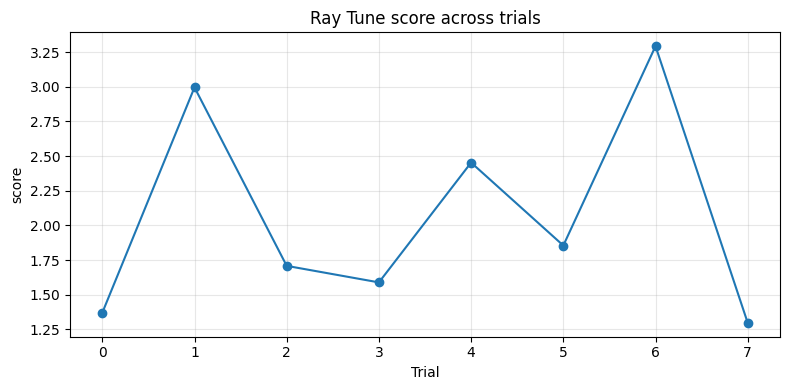

In [14]:
best_config = tune_results.get_best_result().config
print("Best configuration:", best_config)

df = tune_results.get_dataframe()
display(df)

df_sorted = df.reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(df_sorted.index.to_numpy(), df_sorted["score"].to_numpy(), marker="o")
plt.xlabel("Trial")
plt.ylabel("score")
plt.title("Ray Tune score across trials")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluation

In [15]:

graphs_0 = [
    train_generator(
        cls_idx=0, 
        max_nodes=config['tune']['max_nodes'], 
        iters_per_sample=config['train']['iters_per_sample'], 
        data=data, 
        mean_embeds=mean_embeds, 
        explainee=explainee, 
        ged_model=model, 
        w_pred  = float(best_config["pred_weight"]), 
        w_embed = float(best_config["embed_weight"]),
        w_ged   = float(best_config["ged_weight"]), 
        w_mcs   = float(best_config["mcs_weight"]),
        w_spec  = float(best_config["spectral_weight"]),
        w_wl    = float(best_config["wl_weight"]),
        use_omega = bool(best_config["use_omega"])
    ) for _ in range(config['train']['samples_per_trial'])
]

graphs_1 = [
    train_generator(
        cls_idx=1, 
        max_nodes=config['tune']['max_nodes'], 
        iters_per_sample=config['train']['iters_per_sample'], 
        data=data, 
        mean_embeds=mean_embeds, 
        explainee=explainee, 
        ged_model=model, 
        w_pred  = float(best_config["pred_weight"]), 
        w_embed = float(best_config["embed_weight"]),
        w_ged   = float(best_config["ged_weight"]), 
        w_mcs   = float(best_config["mcs_weight"]),
        w_spec  = float(best_config["spectral_weight"]),
        w_wl    = float(best_config["wl_weight"]),
        use_omega = bool(best_config["use_omega"])
    ) for _ in range(config['train']['samples_per_trial'])
]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [19]:
import new_src.graph_level_dist
importlib.reload(new_src.graph_level_dist)

from new_src.graph_level_dist import neural_approx_ged_dist
dist_to_0 = neural_approx_ged_dist(cls_split[0], model)
dist_to_1 = neural_approx_ged_dist(cls_split[1], model)

import new_src.eval
importlib.reload(new_src.eval)

from new_src.eval import eval_summary


eval_summary(
    explainee=explainee, 
    gen_graphs_0=graphs_0,
    gen_graphs_1=graphs_1, 
    obs_graphs_0=cls_split[0], 
    obs_graphs_1=cls_split[1], 
    dist_to_0=dist_to_0, 
    dist_to_1=dist_to_1
)

Prediction Interval Class 0 0.9671213626861572 +/- 0.15691636502742767

Prediction Interval Class 1 0.9992766380310059 +/- 0.0026446871925145388

Counterfactual Shift to Class 0 0.4815189838409424 +/- 0.4491441249847412

Counterfactual Shift to Class 1 0.6266040205955505 +/- 0.2638353109359741

Class 0 Perturbation Sensitivity 0.03557431325316429 +/- 0.15560948848724365

Class 1 Perturbation Sensitivity 0.004707686137408018 +/- 0.06329674273729324

Relative Distance to Class 0 -0.05011507868766785 +/- 0.2514713406562805 

Relative Distance to Class 1 0.20588180422782898 +/- 0.21237842738628387 



2.8784722802229226

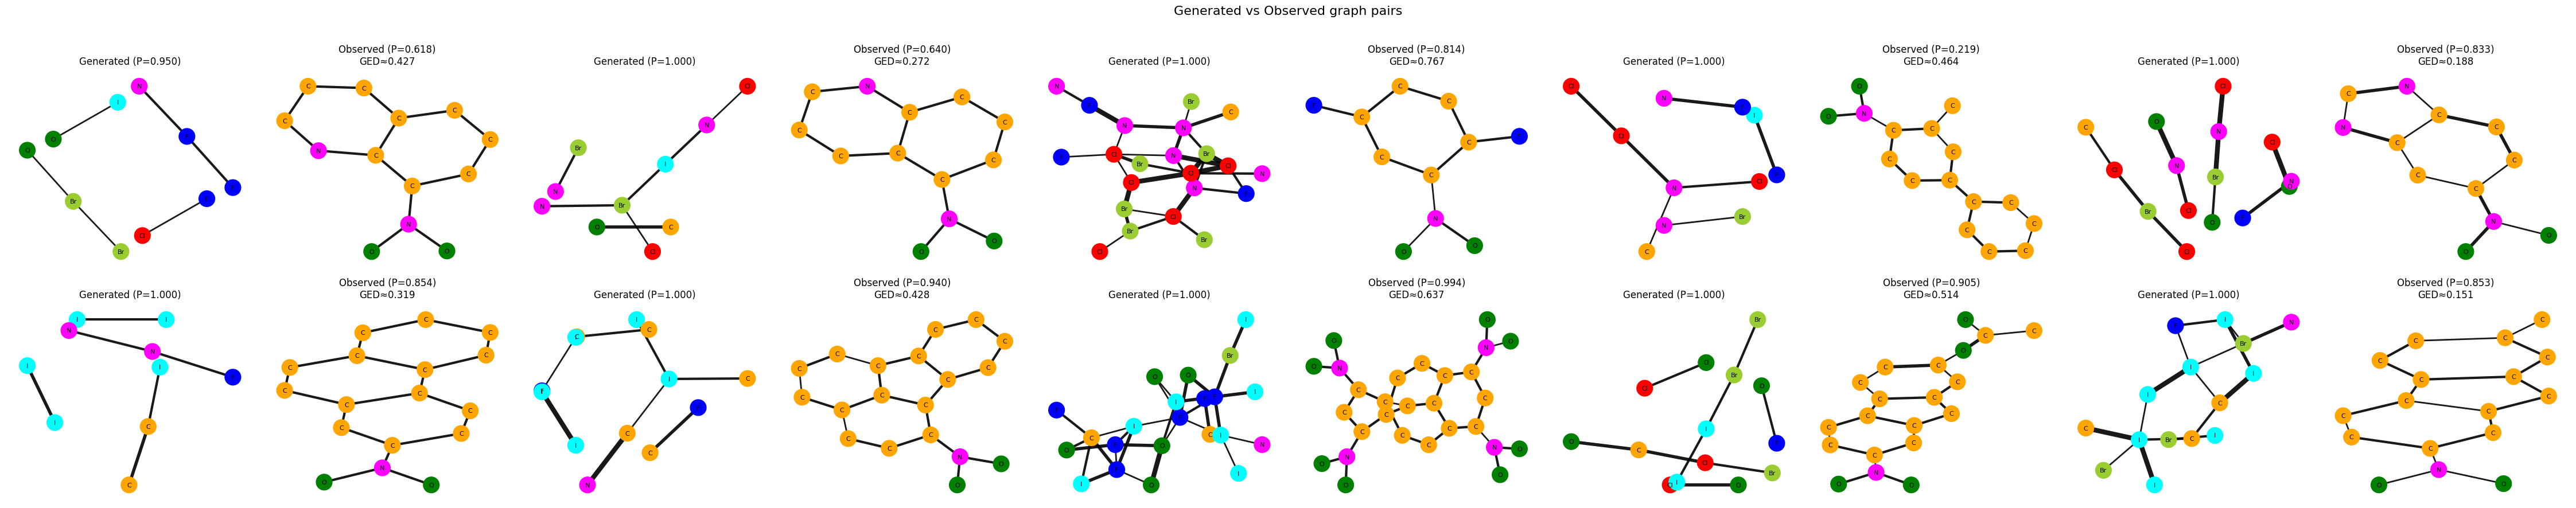

In [17]:
import new_src.utils
importlib.reload(new_src.utils)

from new_src.utils import eval_plot 

eval_plot(
    explainee, 
    graphs_0, 
    graphs_1, 
    obs_graphs_0=cls_split[0], 
    obs_graphs_1=cls_split[1],
    ged_model=model, 
    dataset=data,
    layout="kamada"
)